In [1]:
!python --version
import os
import warnings
print (os.environ['CONDA_DEFAULT_ENV'])

#suppress warnings
warnings.filterwarnings('ignore')

from dask.distributed import LocalCluster
cluster = LocalCluster()          # Fully-featured local Dask cluster
client = cluster.get_client()

client

Python 3.10.16
culRI-Bayesian


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 7
Total threads: 28,Total memory: 62.58 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35817,Workers: 7
Dashboard: http://127.0.0.1:8787/status,Total threads: 28
Started: Just now,Total memory: 62.58 GiB
Comm: tcp://127.0.0.1:43279,Total threads: 4
Dashboard: http://127.0.0.1:37941/status,Memory: 8.94 GiB
Nanny: tcp://127.0.0.1:35685,


# 1. Workbook setups

## 1.1 Import packages

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
import math
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import statsmodels.api as sm

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot

from shapely.geometry import Point, Polygon

from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time

## 1.2 Miscellaneous codes

In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,lon2 = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(lon2,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    lon1, lat1 = origin
    lon2, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient

## 1.3 Dictionaries

In [4]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


## 1.4 Set local paths

In [5]:
# set the path to local folder other than github
login_name = os.getlogin()

### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'

# 2. Import data

## 2.1 Culture Compilation

In [13]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'revised_cultures_GDGT_github_RR2024.xlsx'

culture_df = pd.read_excel(os.path.join(fpath,fname),sheet_name='master_cultures')
culture_df['TEX86'] = np.sum(culture_df[['fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)/np.sum(culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren_prime']],axis=1)

features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
culture_df['ringIndex'] = np.array([culture_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
culture_df['scaledRI'] = culture_df['ringIndex']/4
culture_df['gdgt23ratio'] = culture_df['fGDGT_2']/culture_df['fGDGT_3']
culture_df['methaneIndex'] = culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']].sum(axis=1)/culture_df[['fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']].sum(axis=1)
culture_df['gdgtZeroOverZeroCren'] = (culture_df['fGDGT_0']/culture_df[['fGDGT_0','fGDGT_cren']].sum(axis=1))


#### copy culture_df to culture_df2 to keep the original df
culture_df2 = culture_df.dropna(how='any', subset=['TEX86']).reset_index(drop=True)
culture_df2['methaneIndex']= culture_df2['methaneIndex'].fillna(-999)
culture_df2['gdgtZeroOverZeroCren'] = culture_df2['fGDGT_0'].fillna(-999)

culture_df2['TEX_RI'] = (-0.77*culture_df2['TEX86']
                                )+(3.32*culture_df2['TEX86']**2
                                   )+(1.59)
culture_df2['deltaRI'] = culture_df2['TEX_RI']-culture_df2['ringIndex']



In [7]:
fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'texmesocosms.csv'
mesocosm_df = pd.read_csv(os.path.join(fpath,fname))

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,TEXAS_PSM_culture_RR081,Elling_etal_unpubl_Nitrosopumilus piranensis D...,Elling et al. Unpublished,32,0.592257,3.097891,0.774473,2.148000,8.0,p__Thermoproteota,...,0.091016,0.084947,0.039547,0.671876,0.007709,culture,0.240768,0.135051,0,culture-temperature_Marine mesophile
170,TEXAS_PSM_culture_RR082,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,15,0.339403,1.425528,0.356382,2.135099,5.1,p__Thermoproteota,...,0.133710,0.044745,0.020957,0.281869,0.002995,culture,0.411773,0.646601,0,culture-temperature_Marine mesophile
171,TEXAS_PSM_culture_RR083,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,20,0.368559,1.569168,0.392292,2.012291,5.1,p__Thermoproteota,...,0.174887,0.062104,0.030862,0.285259,0.009112,culture,0.476416,0.605469,0,culture-temperature_Marine mesophile
172,TEXAS_PSM_culture_RR084,Elling_etal_unpubl_Nitrosopumilus adriaticus C...,Elling et al. Unpublished,25,0.402291,1.778023,0.444506,1.436124,5.1,p__Thermoproteota,...,0.177253,0.063708,0.044361,0.323836,0.011232,culture,0.459908,0.539644,0,culture-temperature_Marine mesophile


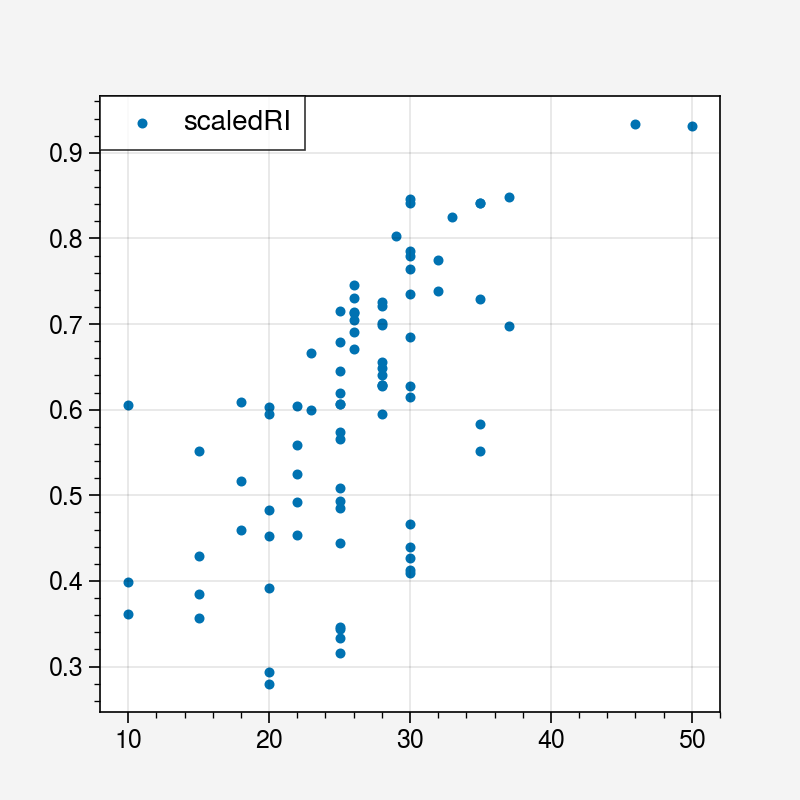

In [17]:
plot_data = culture_df2[culture_df2['GTDB_family'] == 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_1 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
                        'Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_1)+1)]
plot_data_1.insert(0,'sampleID',temp_sampleID)
plot_data_1['datatype'] = 'culture'
plot_data_1['methaneIndex'] = np.sum(plot_data_1[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_1[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_1['gdgtZeroOverZeroCren'] = plot_data_1['fGDGT_0']/(plot_data_1['fGDGT_0'] + plot_data_1['fGDGT_cren'])
plot_data_1['BIT'] = 0
plot_data_1['violin_bins'] = plot_data_1['experiment_setup']+'_'+plot_data_1['organism_broadClass']

display(plot_data_1)
plt.scatter(plot_data_1['Temperature'],plot_data_1['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


In [18]:
plot_data_1[plot_data_1['Strains']=='PS0']

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
85,TEXAS_PSM_culture_RR036,Qin2015_017_Nitrosopumilus ureiphilus PS0_Cult...,Qin et al. (2015) PNAS,25,0.378578,2.480200,0.620050,3.021858,4.0,p__Thermoproteota,...,0.125900,0.055300,0.018300,0.544100,0.003100,culture,0.267176,0.317657,0,culture-temperature_Marine mesophile
91,TEXAS_PSM_culture_RR042,Qin2015_023_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.830204,2.853456,0.713364,8.598726,4.0,p__Thermoproteota,...,0.062419,0.270081,0.031409,0.535461,0.003701,culture,0.402969,0.153274,0,culture-oxygen_Marine mesophile
92,TEXAS_PSM_culture_RR043,Qin2015_024_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.800980,2.856128,0.714032,7.350575,4.0,p__Thermoproteota,...,0.073137,0.255928,0.034817,0.538069,0.003602,culture,0.401834,0.149320,0,culture-oxygen_Marine mesophile
93,TEXAS_PSM_culture_RR044,Qin2015_025_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.736403,2.984594,0.746148,6.003268,4.0,p__Thermoproteota,...,0.079032,0.183774,0.030612,0.605142,0.006403,culture,0.324232,0.135734,0,culture-oxygen_Marine mesophile
94,TEXAS_PSM_culture_RR045,Qin2015_026_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.679259,2.923469,0.730867,5.881041,4.0,p__Thermoproteota,...,0.090036,0.158263,0.026911,0.603541,0.005502,culture,0.311234,0.160918,0,culture-oxygen_Marine mesophile
95,TEXAS_PSM_culture_RR046,Qin2015_027_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.594332,2.817190,0.704298,5.584071,4.0,p__Thermoproteota,...,0.104563,0.126276,0.022614,0.593756,0.004303,culture,0.297650,0.200054,0,culture-oxygen_Marine mesophile
96,TEXAS_PSM_culture_RR047,Qin2015_028_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.542880,2.761886,0.690471,4.869369,4.0,p__Thermoproteota,...,0.113102,0.108197,0.022220,0.587529,0.003904,culture,0.291657,0.219311,0,culture-oxygen_Marine mesophile
97,TEXAS_PSM_culture_RR048,Qin2015_029_Nitrosopumilus ureiphilus PS0_T26_...,Qin et al. (2015) PNAS,26,0.454837,2.685849,0.671462,3.963918,4.0,p__Thermoproteota,...,0.118995,0.076962,0.019416,0.585769,0.002902,culture,0.267862,0.250672,0,culture-oxygen_Marine mesophile


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
55,TEXAS_PSM_culture_RR001,Elling2017_culture_ThAOA_totalGDGTs_Nitrosocal...,Elling et al. (2017) Environmnental Microbiology,72,0.612884,3.129260,0.782315,1.885747,25.1,p__Thermoproteota,...,0.050936,0.021266,0.011277,0.702391,0.048099,culture,0.100099,0.191187,0,culture-temperature_Terrestrial thermophile
56,TEXAS_PSM_culture_RR002,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,35,0.920575,3.640753,0.910188,0.907867,15.0,p__Thermoproteota,...,0.034385,0.040728,0.044861,0.534625,0.312957,culture,0.123998,0.057212,0,culture-temperature_Terrestrial thermophile
57,TEXAS_PSM_culture_RR003,Elling2017_culture_ThAOA_totalGDGTs_Nitrososph...,Elling et al. (2017) Environmnental Microbiology,46,0.966310,3.894759,0.973690,0.299016,15.0,p__Thermoproteota,...,0.011710,0.002984,0.009978,0.638877,0.322909,culture,0.025011,0.020756,0,culture-temperature_Terrestrial thermophile
58,TEXAS_PSM_culture_RR004,Pearson2008_027_Pure Cultures-Acidilobus sacch...,Pearson et al. (2008) Applied and Environmenta...,82,1.000000,3.000000,0.750000,0.000000,21.0,p__Thermoproteota,...,0.000000,0.000000,1.000000,0.000000,0.000000,culture,1.000000,NaN,0,culture-temperature_Terrestrial thermoacidophile
59,TEXAS_PSM_culture_RR005,Pearson2008_028_Pure Cultures-Metallosphaera s...,Pearson et al. (2008) Applied and Environmenta...,75,0.761905,1.942857,0.485714,0.920000,18.0,p__Thermoproteota,...,0.214286,0.328571,0.357143,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial thermoacidophile
60,TEXAS_PSM_culture_RR006,Pearson2008_029_Pure Cultures-Sulfolobus solfa...,Pearson et al. (2008) Applied and Environmenta...,85,0.947368,2.684211,0.671053,0.285714,19.0,p__Thermoproteota,...,0.052632,0.210526,0.736842,0.000000,0.000000,culture,1.000000,NaN,0,culture-temperature_Terrestrial thermoacidophile
61,TEXAS_PSM_culture_RR007,Pearson2008_030_Pure Cultures-Vulcanisaeta mou...,Pearson et al. (2008) Applied and Environmenta...,85,0.869565,2.111111,0.527778,0.428571,23.0,p__Thermoproteota,...,0.111111,0.222222,0.518519,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic
62,TEXAS_PSM_culture_RR008,Pearson2008_034_Pure Cultures-Thermoproteus uz...,Pearson et al. (2008) Applied and Environmenta...,85,0.875000,1.809524,0.452381,0.750000,22.0,p__Thermoproteota,...,0.095238,0.285714,0.380952,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial thermoacidophile
63,TEXAS_PSM_culture_RR009,Pearson2008_032_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.830508,2.029412,0.507353,0.633333,20.0,p__Thermoproteota,...,0.147059,0.279412,0.441176,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic
64,TEXAS_PSM_culture_RR010,Pearson2008_033_Pure Cultures-Desulfurococcus ...,Pearson et al. (2008) Applied and Environmenta...,85,0.837838,1.955556,0.488889,0.550000,20.0,p__Thermoproteota,...,0.133333,0.244444,0.444444,0.000000,0.000000,culture,1.000000,1.000000,0,culture-temperature_Terrestrial hyperthermophilic


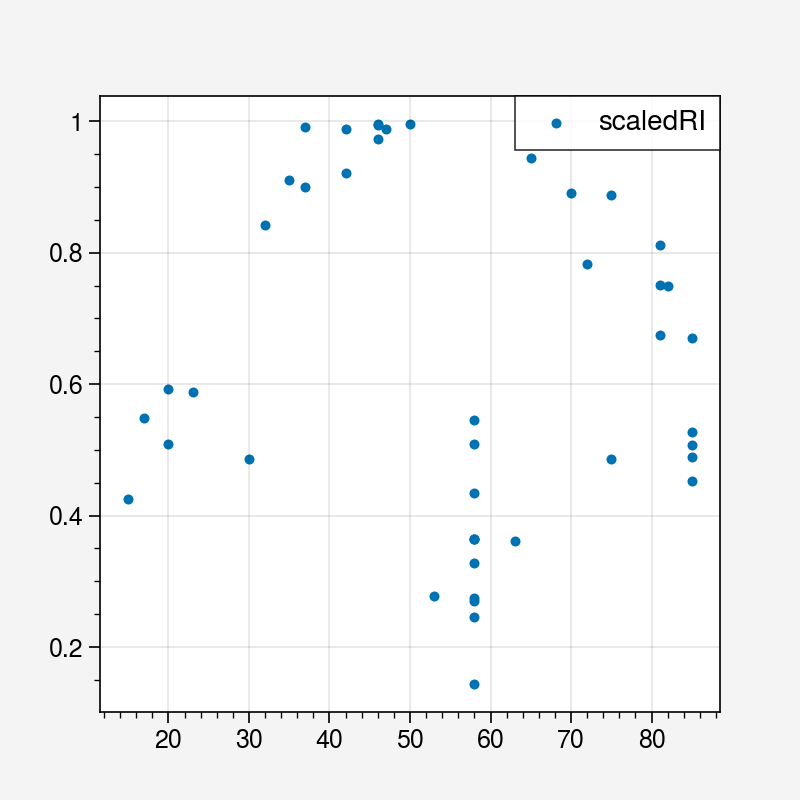

In [19]:
plot_data = culture_df2[culture_df2['GTDB_family'] != 'f__Nitrosopumilaceae']
plot_data = plot_data[plot_data['Broad Filtration Class']=='Total GDGTs']
plot_data_2 = plot_data[['sampleName','Source','reported_Temp','TEX86',
                         'ringIndex','scaledRI','gdgt23ratio','phyloT_order',
                        'GTDB_phylum','NCBI_phylum','GTDB_class','NCBI_class','GTDB_order','NCBI_order',
                        'GTDB_family','NCBI_family','GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
                        'Strains','experiment_setup','organism_broadClass','organism_broadClass2','organism_broadClass3',
                        'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime'
                        ]].rename(columns={'reported_Temp':'Temperature'})

temp_sampleID = ['TEXAS_PSM_culture_RR'+str(i).zfill(3) for i in range(1,len(plot_data_2)+1)]
plot_data_2.insert(0,'sampleID',temp_sampleID)
plot_data_2['datatype'] = 'culture'
plot_data_2['methaneIndex'] = np.sum(plot_data_2[['fGDGT_1', 'fGDGT_2', 'fGDGT_3']],axis=1)/np.sum(plot_data_2[['fGDGT_1','fGDGT_2','fGDGT_3', 'fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_2['gdgtZeroOverZeroCren'] = plot_data_2['fGDGT_0']/(plot_data_2['fGDGT_0'] + plot_data_2['fGDGT_cren'])
plot_data_2['BIT'] = 0
plot_data_2['violin_bins'] = plot_data_2['experiment_setup']+'_'+plot_data_2['organism_broadClass']

display(plot_data_2)
plt.scatter(plot_data_2['Temperature'],plot_data_2['scaledRI'],marker='.',label=r'scaledRI')
plt.legend(loc='best',fontsize=10)


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,fGDGT_0,fGDGT_1,...,NCBI_family,GTDB_genus,NCBI_genus,GTDB_species,NCBI_species,Strains,experiment_setup,organism_broadClass,organism_broadClass2,organism_broadClass3
0,TEXAS_PSM_mesocosm_RR001,meso_001,Wuchter2004,10,0.334578,1.967739,0.491935,2.685656,0.416348,0.096573,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
1,TEXAS_PSM_mesocosm_RR002,meso_002,Wuchter2004,15,0.288381,1.939119,0.484780,2.190909,0.434734,0.088906,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
2,TEXAS_PSM_mesocosm_RR003,meso_003,Wuchter2004,15,0.239814,1.856318,0.464080,2.250000,0.451412,0.097281,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
3,TEXAS_PSM_mesocosm_RR004,meso_004,Wuchter2004,22,0.466403,2.991935,0.747984,2.858779,0.196237,0.051843,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
4,TEXAS_PSM_mesocosm_RR005,meso_005,Wuchter2004,25,0.461538,3.058343,0.764586,1.763466,0.193623,0.040726,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
5,TEXAS_PSM_mesocosm_RR006,meso_006,Wuchter2004,25,0.483547,3.228140,0.807035,3.037383,0.145988,0.043298,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
6,TEXAS_PSM_mesocosm_RR007,meso_007,Wuchter2004,30,0.527554,3.043329,0.760832,4.415385,0.153019,0.071979,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
7,TEXAS_PSM_mesocosm_RR008,meso_008,Wuchter2004,35,0.705459,3.162726,0.790682,5.052474,0.108380,0.057469,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
8,TEXAS_PSM_mesocosm_RR009,meso_009,Wuchter2004,13,0.263181,1.874010,0.468502,2.705674,0.480893,0.057159,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm
9,TEXAS_PSM_mesocosm_RR010,meso_010,Wuchter2004,15,0.309940,2.180438,0.545109,2.971429,0.371221,0.090714,...,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm,mesocosm


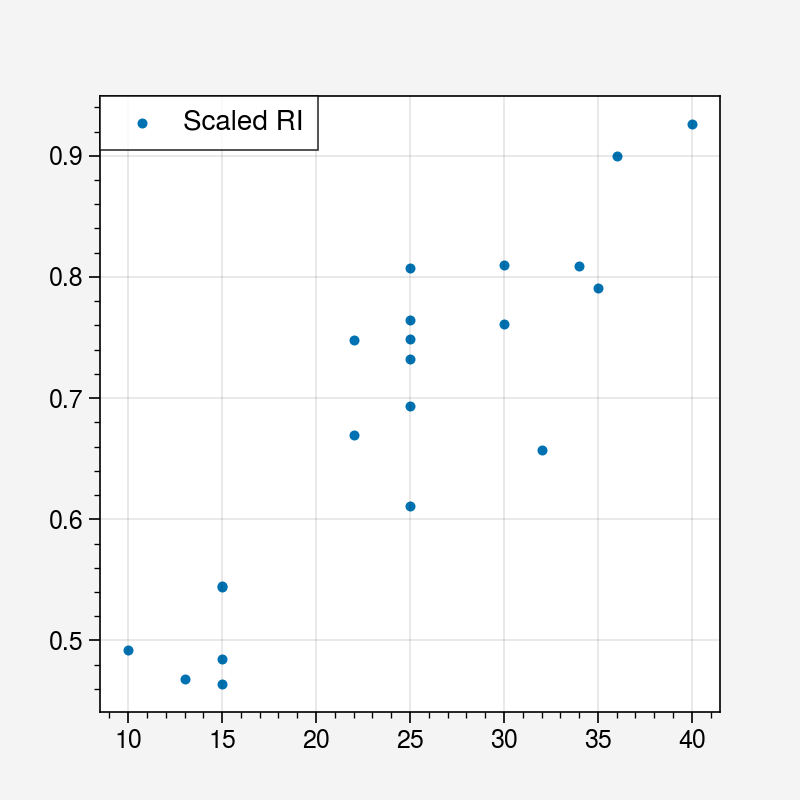

In [20]:
features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
mesocosm_df['ringIndex'] = np.array([mesocosm_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
mesocosm_df['scaledRI'] = mesocosm_df['ringIndex']/4
mesocosm_df['gdgt23ratio'] = mesocosm_df['fGDGT_2']/mesocosm_df['fGDGT_3']
mesocosm_df['sampleName'] = ['meso_'+f'{i+1}'.zfill(3) for i in range(len(mesocosm_df))]
plot_data_3 = mesocosm_df[['sampleName','Source','Temperature','tex86',
                           'ringIndex','scaledRI','gdgt23ratio',   
                           'fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3',
                           'fGDGT_cren', 'fGDGT_cren_prime']].rename(columns={
                                                                        'tex86':'TEX86',
                                                                        })

temp_sampleID = ['TEXAS_PSM_mesocosm_RR'+str(i).zfill(3) for i in range(1,len(plot_data_3)+1)]
plot_data_3.insert(0,'sampleID',temp_sampleID)
plot_data_3['datatype'] = 'mesocosm'
plot_data_3['methaneIndex'] = np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3']],axis=1)/np.sum(plot_data_3[['fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']],axis=1)
plot_data_3['gdgtZeroOverZeroCren'] = plot_data_3['fGDGT_0']/(plot_data_3['fGDGT_0'] + plot_data_3['fGDGT_cren'])
plot_data_3['BIT'] = 0
plot_data_3['phyloT_order'] = 0
new_cols = [
    'GTDB_phylum','NCBI_phylum','GTDB_class','GTDB_family',
    'NCBI_class','GTDB_order','NCBI_order','NCBI_family',
    'GTDB_genus','NCBI_genus','GTDB_species','NCBI_species',
    'Strains','experiment_setup',
    'organism_broadClass','organism_broadClass2','organism_broadClass3']
for col in new_cols:
    plot_data_3[col] = 'mesocosm'
    

display(plot_data_3)
plt.scatter(plot_data_3['Temperature'],plot_data_3['scaledRI'],marker='.',label=r'Scaled RI')
plt.legend(loc='upper left',fontsize=10)

In [21]:
merged_df = pd.concat([plot_data_1,plot_data_2,plot_data_3],axis=0)
display(merged_df)

fpath = os.path.join(local_github_path,'spreadsheets')
fname = r'culture_mesocosm_combined_rev_030425.csv'
merged_df.to_csv(os.path.join(fpath,fname),index=False)

,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_1,fGDGT_2,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins
17,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.195035,0.060284,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,culture-temperature_Terrestrial thermophile
18,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.054469,0.019553,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,culture-temperature_Terrestrial thermophile
19,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.060683,0.018963,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,culture-temperature_Terrestrial thermophile
20,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.101818,0.172121,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,culture-temperature_Marine mesophile
21,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.109714,0.266286,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,culture-temperature_Marine mesophile
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.073897,0.035219,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN
17,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.051583,0.055801,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN
18,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.049939,0.045612,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN
19,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.023916,0.054250,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN
